In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [2]:
import src.preference_factors.build_datasets as bd


In [3]:
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_daily_with_tickers.csv",
    market_caps_file="sp500_market_caps_daily.csv",
    ff_factors_file="ff_factors_daily.csv",
    frequency="daily"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


In [4]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

In [5]:
asset_returns = bd.build_returns_dataset("sp500_returns_daily_with_tickers.csv", frequency="daily")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=252, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=252, min_obs=10)



Estimating rolling betas: 100%|██████████| 13367/13367 [11:29<00:00, 19.40it/s]


In [6]:
results = run_full_factor_pipeline(
    beta1_df=betas_ebc,
    beta2_df=betas_cw_ebc,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'daily'
)

results["mean_grid"]

forming portfolios: 100%|██████████| 13367/13367 [01:21<00:00, 164.44it/s]


,1,2,3
1,0.000569,0.000642,0.000699
2,0.000509,0.000543,0.000574
3,0.000458,0.000514,0.000517


In [7]:
results["portrets_wide"][:5]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1971-12-29,0.000135,0.003076,0.003025,0.005297,0.004070,0.008437,0.007212,0.007641,0.011069
1971-12-30,-0.005138,-0.003378,-0.002723,-0.004188,-0.003279,0.000158,-0.001937,0.005155,0.003048
1971-12-31,0.008176,0.008120,0.007600,0.001370,0.004433,0.003993,0.003615,0.003979,0.006136
1972-01-03,-0.000056,0.003051,0.009906,-0.000123,0.000981,-0.000676,-0.002875,0.002573,0.001883
1972-01-04,0.011456,0.011619,0.009722,-0.001124,0.001938,-0.001370,0.004143,0.002021,0.001804


In [8]:
from pathlib import Path
import src.FamaMacBeth.backtest as backtest
'''(
    load_monthly_inputs,
    backtest_quantile_portfolios,
    compute_excess_returns,
)
'''
import src.FamaMacBeth.plots as plots
'''(
    plot_cum_log_returns,
    plot_expected_return_grid,
)
'''

'(\n    plot_cum_log_returns,\n    plot_expected_return_grid,\n)\n'

In [9]:
# ============================
# USER PARAMETERS
# ============================
start_date = "1970-01-01"
use_excess_returns = True

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = backtest.load_daily_inputs(DATA_RAW_DIR)

In [10]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
    frequency='daily'
)

if use_excess_returns:
    quantile_portfolios_returns = backtest.compute_excess_returns(
        quantile_portfolios_returns, rf, start_date=start_date
    )
else:
    quantile_portfolios_returns = quantile_portfolios_returns.loc[start_date:]

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

In [11]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


In [12]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [15]:
complete_df['CW-RF'] = complete_df['CW'] - complete_df['RF']

In [16]:
selected_columns = ['CW-RF','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

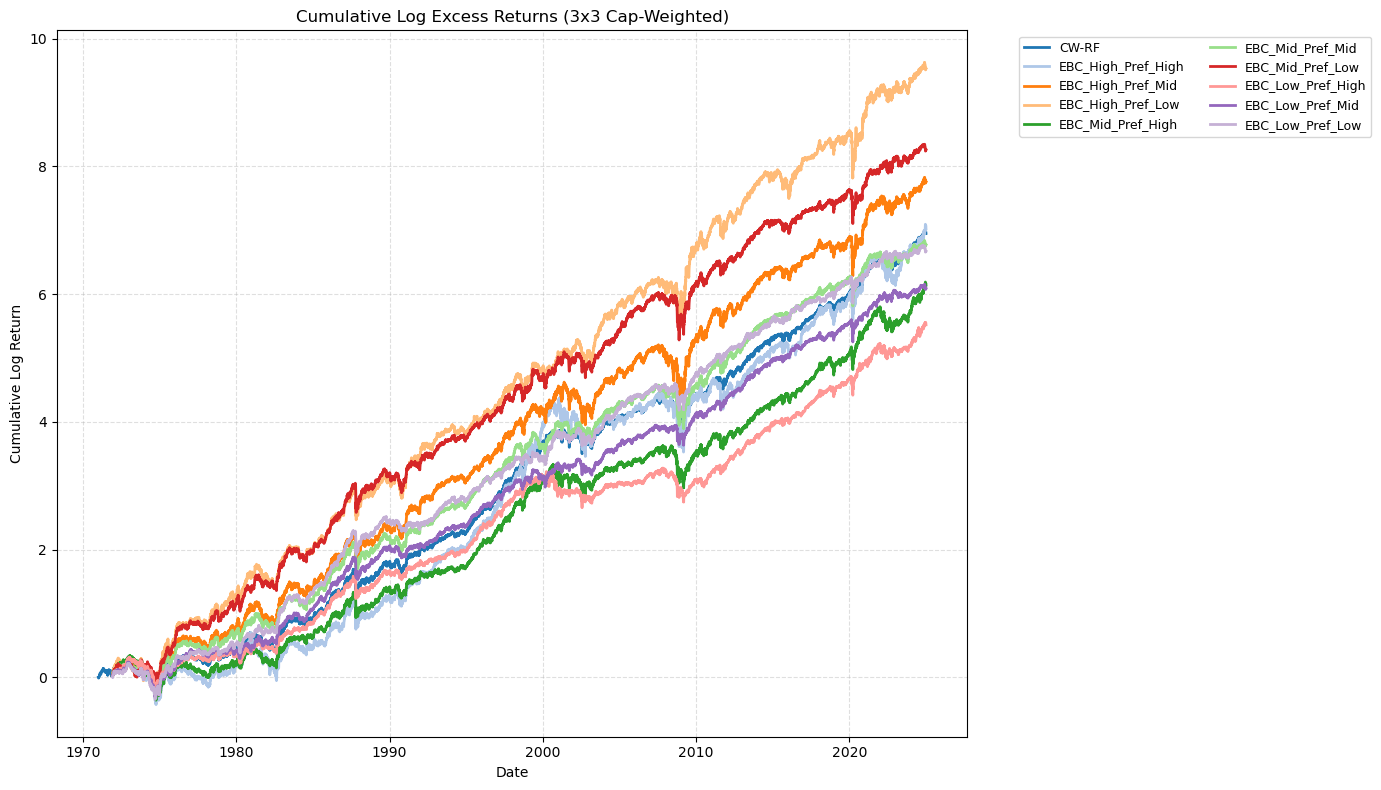

In [17]:
# ============================
# PLOTS
# ============================
plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)"
)

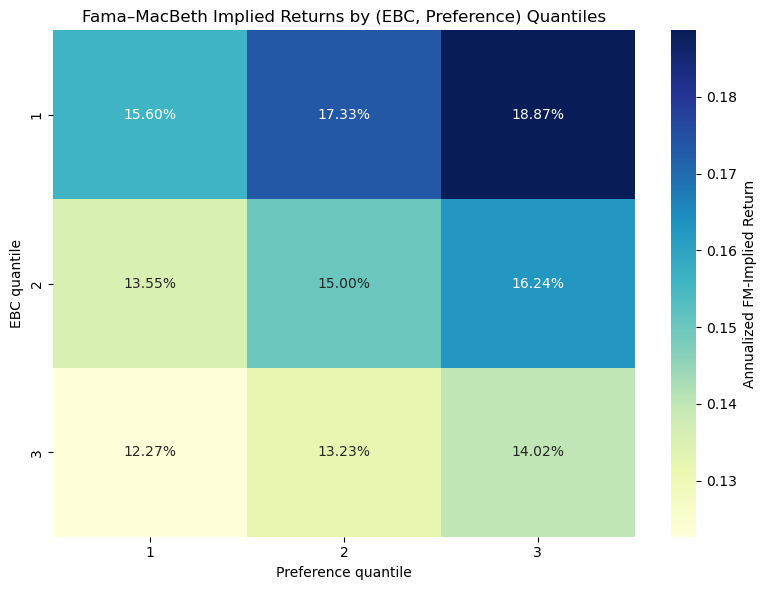

In [18]:
# FM expected-return grid (annualized %)
plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2, frequency = "daily")

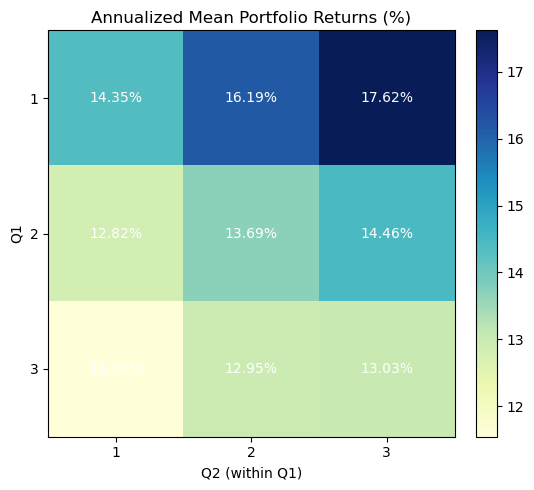

In [19]:
plots.plot_mean_grid(results["mean_grid"], annualize=True, frequency = 'daily')

In [20]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [21]:
quantile_portfolios_returns.index.name = "date"

In [22]:
quantile_portfolios_returns

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
date,,,,,,,,,
1970-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640
2024-12-26,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003
2024-12-27,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013


In [23]:
quantile_portfolios_returns.to_csv(DATA_PROCESSED_DIR / "daily_quantile_returns_3x3.csv")